# Example: Optimize yaw for a single wind speed and multiple wind directions

[Serial Refine] Processing pass=0, turbine_depth=0 (0.0%)
[Serial Refine] Processing pass=0, turbine_depth=1 (16.7%)
[Serial Refine] Processing pass=0, turbine_depth=2 (33.3%)
[Serial Refine] Processing pass=1, turbine_depth=0 (50.0%)
[Serial Refine] Processing pass=1, turbine_depth=1 (66.7%)


floris.floris_model.FlorisModel WARNING Deleting stored wind_data information.


[Serial Refine] Processing pass=1, turbine_depth=2 (83.3%)
Optimization results:
     wind_direction  wind_speed  turbulence_intensity   yaw_angles_opt  \
0               0.0         8.0                  0.06  [0.0, 0.0, 0.0]   
1               3.0         8.0                  0.06  [0.0, 0.0, 0.0]   
2               6.0         8.0                  0.06  [0.0, 0.0, 0.0]   
3               9.0         8.0                  0.06  [0.0, 0.0, 0.0]   
4              12.0         8.0                  0.06  [0.0, 0.0, 0.0]   
..              ...         ...                   ...              ...   
115           345.0         8.0                  0.06  [0.0, 0.0, 0.0]   
116           348.0         8.0                  0.06  [0.0, 0.0, 0.0]   
117           351.0         8.0                  0.06  [0.0, 0.0, 0.0]   
118           354.0         8.0                  0.06  [0.0, 0.0, 0.0]   
119           357.0         8.0                  0.06  [0.0, 0.0, 0.0]   

     farm_power_opt  farm_powe

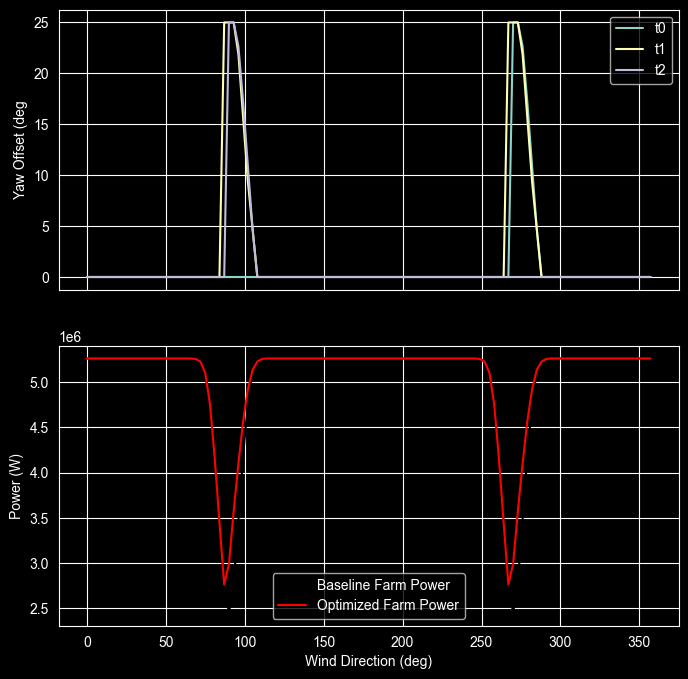

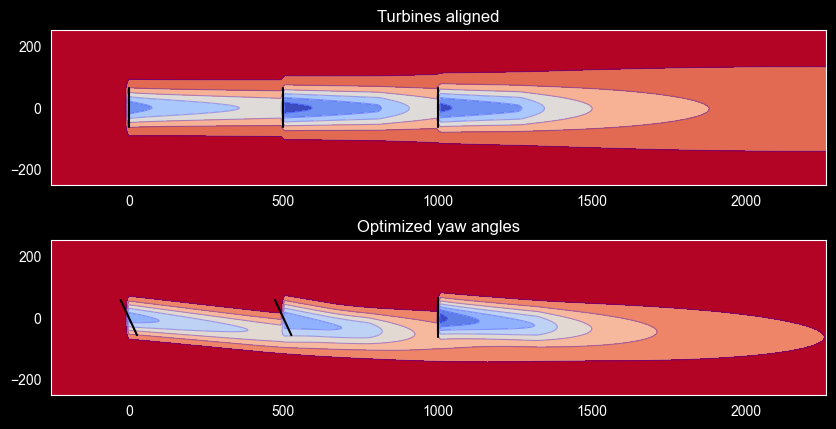

In [5]:
"""Example: Optimize yaw for a single wind speed and multiple wind directions

Use the serial-refine method to optimize the yaw angles for a 3-turbine wind farm

"""

import matplotlib.pyplot as plt
import numpy as np


import floris.flow_visualization as flowviz
import floris.layout_visualization as layoutviz
from floris import FlorisModel, TimeSeries
from floris.optimization.yaw_optimization.yaw_optimizer_sr import YawOptimizationSR
# from generate.layout import generate_layout_3
# Load the default example floris object
fmodel = FlorisModel("../inputs/cc.yaml")

# Define an inflow that
# keeps wind speed and TI constant while sweeping the wind directions
wind_directions = np.array([270.0])
time_series = TimeSeries(
    wind_directions=wind_directions,
    wind_speeds=9.6,
    turbulence_intensities=0.06,
)

# Reinitialize as a 3-turbine using the above inflow
# D = 126.0 # Rotor diameter for the NREL 5 MW
# M3 = 25
# dx3 = 6.3
# dy3 = 6.8
# offset3 = 1
# layout_x3, layout_y3 = generate_layout_3(D, M3, dx3, dy3, offset3)

fmodel.set(
    layout_x=[0.0, 500.0, 1000.0],
    layout_y=[0.0, 0.0, 0.0],
    wind_data=time_series,
)

# # Initialize optimizer object and run optimization using the Serial-Refine method
# yaw_opt = YawOptimizationSR(fmodel)
# df_opt = yaw_opt.optimize()
#
# print("Optimization results:")
# print(df_opt)
#
# # Split out the turbine results
# for t in range(3):
#     df_opt['t%d' % t] = df_opt.yaw_angles_opt.apply(lambda x: x[t])
#
# # Show the results
# fig, axarr = plt.subplots(2,1,sharex=True,sharey=False,figsize=(8,8))
#
# # Yaw results
# ax = axarr[0]
# for t in range(3):
#     ax.plot(df_opt.wind_direction,df_opt['t%d' % t],label='t%d' % t)
# ax.set_ylabel('Yaw Offset (deg')
# ax.legend()
# ax.grid(True)
#
# # Power results
# ax = axarr[1]
# ax.plot(df_opt.wind_direction,df_opt.farm_power_baseline,color='k',label='Baseline Farm Power')
# ax.plot(df_opt.wind_direction,df_opt.farm_power_opt,color='r',label='Optimized Farm Power')
# ax.set_ylabel('Power (W)')
# ax.set_xlabel('Wind Direction (deg)')
# ax.legend()
# ax.grid(True)

# Visualize results for a single wind direction (270 deg) and wind speed (8 m/s)
fig, axarr = plt.subplots(2, 1, figsize=(10, 5), sharex=False)
ax = axarr[0] # Baseline aligned operation
fmodel.reset_operation()
fmodel.set(wind_directions=[270.0], wind_speeds=[8.0], turbulence_intensities=[0.06])
fmodel.run()
horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0)
flowviz.visualize_cut_plane(horizontal_plane, ax=ax)
layoutviz.plot_turbine_rotors(fmodel, ax=ax)
ax.set_title("Turbines aligned")

ax = axarr[1] # Optimized yaw angles
optimal_yaw_angles = (
    df_opt[(df_opt["wind_direction"] == 270.0) & (df_opt["wind_speed"] == 8.0)]
    .yaw_angles_opt.values[0]
).reshape(1,-1)

print(np.shape(optimal_yaw_angles))
fmodel.set(yaw_angles=optimal_yaw_angles)
fmodel.run()
horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0)
flowviz.visualize_cut_plane(horizontal_plane, ax=ax)
layoutviz.plot_turbine_rotors(fmodel, ax=ax, yaw_angles=optimal_yaw_angles)
ax.set_title("Optimized yaw angles")

plt.show()
import warnings
warnings.filterwarnings('ignore')

In [7]:
optimal_yaw_angles.shape

(1, 3)